In [1]:
# Cell 0: Load configuration and select active checkpoint
from pathlib import Path
import yaml

# ---------------------------------------------------------
# Resolve project paths
# ---------------------------------------------------------
notebook_dir = Path().resolve()
project_root = notebook_dir.parent

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    rml2018_cfg = local_cfg.get('datasets', {}).get('rml2018', {})
    H5_PATH = Path(rml2018_cfg.get('hdf5', '/scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5'))
    CLASSES_PATH = Path(rml2018_cfg.get('classes', '/scratch/rameyjm7/datasets/RML2018/classes.txt'))
else:
    H5_PATH = Path('/scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5')
    CLASSES_PATH = Path('/scratch/rameyjm7/datasets/RML2018/classes.txt')

DEFAULT_MODEL = project_root / 'models' / 'rml2018' / 'rml2018_lstm_rnn.keras'
ckpt_dir = project_root / 'models' / 'rml2018' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
outputs_dir = project_root / 'outputs' / 'rml2018'
outputs_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Select active model checkpoint (best if available)
# ---------------------------------------------------------
best_ckpt_txt = ckpt_dir / 'best_checkpoint.txt'
if best_ckpt_txt.exists():
    candidate = Path(best_ckpt_txt.read_text().strip())
    if candidate.exists():
        ACTIVE_MODEL_PATH = candidate
    else:
        print('Warning: best_checkpoint.txt points to a missing file. Falling back to default model.')
        ACTIVE_MODEL_PATH = DEFAULT_MODEL
else:
    ACTIVE_MODEL_PATH = DEFAULT_MODEL

print('Project root     :', project_root)
print('RML2018 HDF5     :', H5_PATH)
print('RML2018 classes  :', CLASSES_PATH)
print('Checkpoint dir   :', ckpt_dir)
print('Outputs dir      :', outputs_dir)
print('Default model    :', DEFAULT_MODEL)
print('Active model path:', ACTIVE_MODEL_PATH)
print('Cell 0 complete: configuration loaded (no training performed).')



Project root     : /home/rameyjm7/workspace/ML-wireless-signal-classification
RML2018 HDF5     : /scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5
RML2018 classes  : /scratch/rameyjm7/datasets/RML2018/classes.txt
Checkpoint dir   : /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/checkpoints
Outputs dir      : /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/rml2018
Default model    : /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/rml2018_lstm_rnn.keras
Active model path: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/checkpoints/rml2018_lstm_finetuned_20260413_213014.keras
Cell 0 complete: configuration loaded (no training performed).


I0000 00:00:1776124806.996137 3623445 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776124807.037655 3623445 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776124823.498166 3623445 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Notebook: /home/rameyjm7/workspace/ML-wireless-signal-classification/notebooks
Data directory: /scratch/rameyjm7/datasets/RML2018
Model will be saved to: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/rml2018_lstm_rnn.keras
Classes: ['128APSK' '128QAM' '16APSK' '16PSK' '16QAM' '256QAM' '32APSK' '32PSK'
 '32QAM' '4ASK' '64APSK' '64QAM' '8ASK' '8PSK' 'AM-DSB-SC' 'AM-DSB-WC'
 'AM-SSB-SC' 'AM-SSB-WC' 'BPSK' 'FM' 'GMSK' 'OOK' 'OQPSK' 'QPSK']
Train/Test split: (57600, 1024, 3) (14400, 1024, 3)


I0000 00:00:1776124866.375628 3623445 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22393 MB memory:  -> device: 0, name: NVIDIA A30, pci bus id: 0000:e1:00.0, compute capability: 8.0
/home/rameyjm7/workspace/ml-env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1024, 128)      │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 218,776 (854.59 KB)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1776124869.046763 3624438 cuda_dnn.cc:461] Loaded cuDNN version 91002


Batch size 256 fits GPU memory.
Selected batch size: 256
Epoch 1/250
225/225 - 20s - 90ms/step - accuracy: 0.0711 - loss: 3.0673 - val_accuracy: 0.1161 - val_loss: 2.8212
Epoch 2/250
225/225 - 19s - 84ms/step - accuracy: 0.1299 - loss: 2.6646 - val_accuracy: 0.1524 - val_loss: 2.5620
Epoch 3/250
225/225 - 19s - 84ms/step - accuracy: 0.1427 - loss: 2.5761 - val_accuracy: 0.1410 - val_loss: 2.5482
Epoch 4/250
225/225 - 19s - 84ms/step - accuracy: 0.1381 - loss: 2.6039 - val_accuracy: 0.1582 - val_loss: 2.5418
Epoch 5/250
225/225 - 19s - 84ms/step - accuracy: 0.1455 - loss: 2.6484 - val_accuracy: 0.1506 - val_loss: 2.5880
Epoch 6/250
225/225 - 19s - 84ms/step - accuracy: 0.1489 - loss: 2.5706 - val_accuracy: 0.1769 - val_loss: 2.5115
Epoch 7/250
225/225 - 19s - 84ms/step - accuracy: 0.1639 - loss: 2.5272 - val_accuracy: 0.1903 - val_loss: 2.4497
Epoch 8/250
225/225 - 19s - 84ms/step - accuracy: 0.1574 - loss: 2.6032 - val_accuracy: 0.1512 - val_loss: 2.6605
Epoch 9/250
225/225 - 19s - 83m

/home/rameyjm7/workspace/ml-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rameyjm7/workspace/ml-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rameyjm7/workspace/ml-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

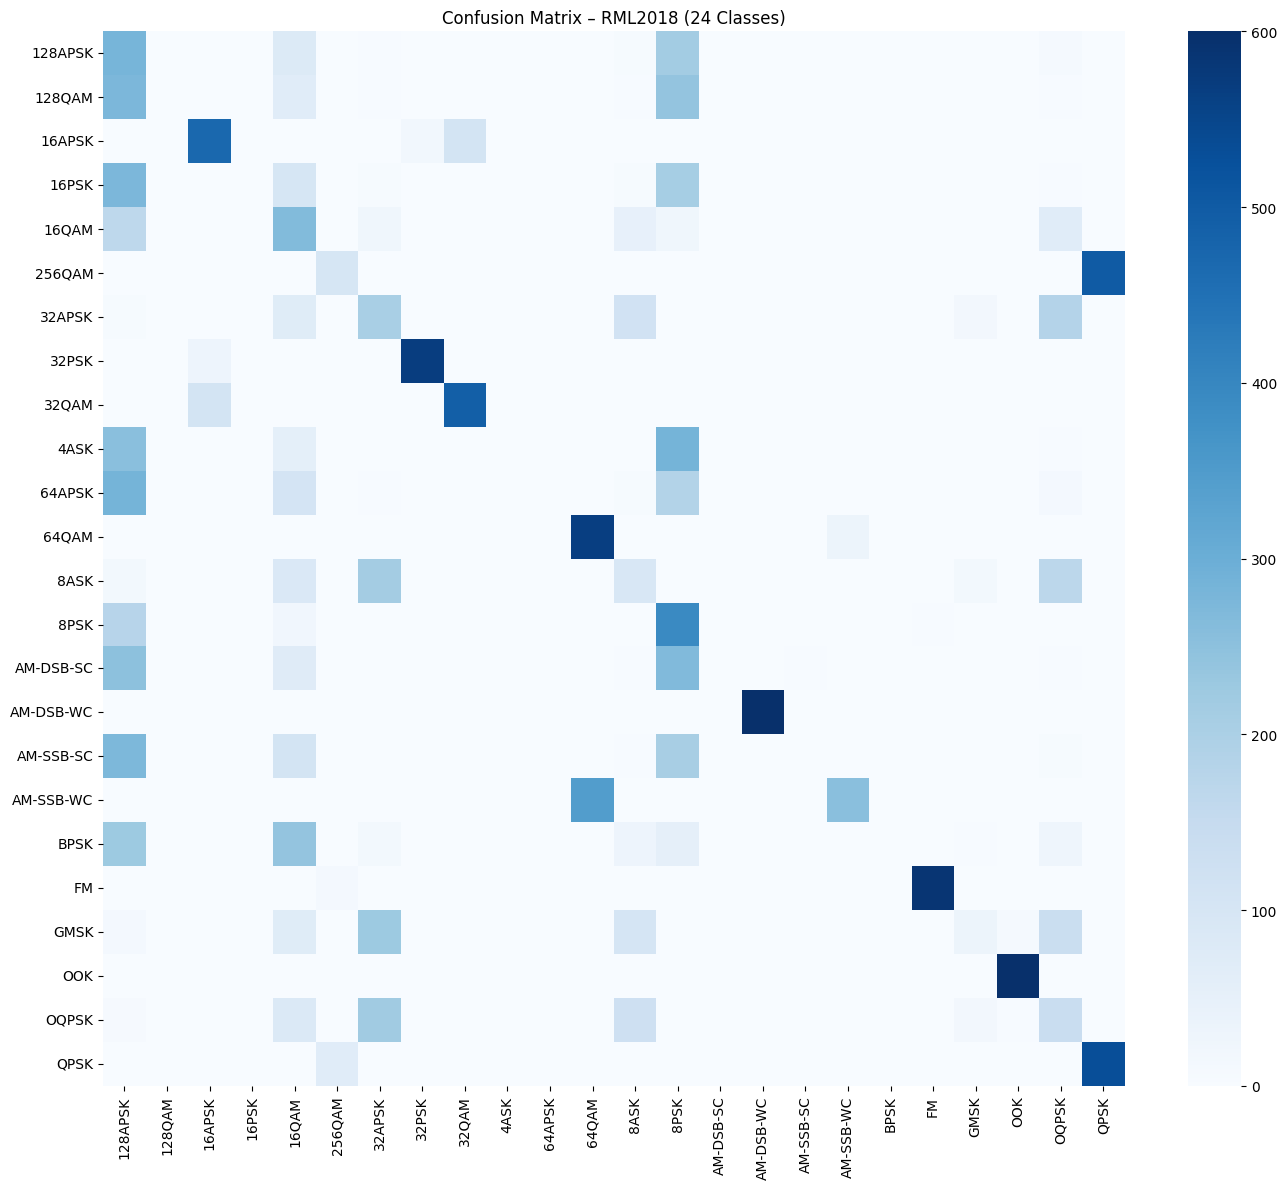

Saving model to: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/rml2018_lstm_balanced.keras
Done.


In [1]:
# Cell 1: LSTM-RNN From Scratch for RML2018.01A Dataset (24 Classes)
# ==============================================================
# LSTM-RNN From Scratch for RML2018.01A Dataset (24 Classes)
# ==============================================================

import h5py, ast, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import os
import yaml

# --------------------------------------------------------------
# Resolve paths relative to project root
# --------------------------------------------------------------
notebook_dir = Path().resolve()
project_root = notebook_dir.parent  # notebooks/ → repo root

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    rml2018_root = Path(local_cfg.get('dataset_root', '/scratch/rameyjm7/datasets')) / 'RML2018'
else:
    rml2018_root = Path('/scratch/rameyjm7/datasets/RML2018')

data_root = rml2018_root
model_out = project_root / "models" / "rml2018" / "rml2018_lstm_rnn.keras"

print("Notebook:", notebook_dir)
print("Data directory:", data_root)
print("Model will be saved to:", model_out)

# -------------------- Parameters --------------------
SNR_RANGE = (12, 20)
MAX_SAMPLES_PER_CLASS = 3000
EPOCHS = 250
BATCH_SIZE = 64
AUTO_BATCH_CANDIDATES = [32, 64, 96, 128, 160, 192, 256]
LR = 1e-4



# -------------------- Auto batch-size selection ---------------------
def auto_select_batch_size(model, X_train, y_train, candidates, fallback=64):
    """Select the largest batch size that fits GPU memory using a 1-step dry-run."""
    gpus = tf.config.list_physical_devices("GPU")
    if not gpus:
        print(f"No GPU detected. Using fallback batch size: {fallback}")
        return int(fallback)

    selected = None
    # Test largest-to-smallest so we keep the biggest stable batch
    for b in sorted(set(int(x) for x in candidates), reverse=True):
        if b <= 0 or len(X_train) < b:
            continue
        try:
            tmp = tf.keras.models.clone_model(model)
            tmp.build(model.input_shape)
            tmp.set_weights(model.get_weights())
            tmp_opt = type(model.optimizer).from_config(model.optimizer.get_config())
            tmp.compile(optimizer=tmp_opt, loss=model.loss, metrics=["accuracy"])

            xb = X_train[:b]
            yb = y_train[:b]
            tmp.train_on_batch(xb, yb)
            selected = b
            print(f"Batch size {b} fits GPU memory.")
            break
        except tf.errors.ResourceExhaustedError:
            print(f"Batch size {b} OOM; trying smaller size...")
        except Exception as exc:
            print(f"Batch size {b} probe failed ({type(exc).__name__}); trying smaller size...")

    if selected is None:
        selected = int(fallback)
        print(f"No candidate batch size succeeded. Using fallback: {selected}")
    else:
        print(f"Selected batch size: {selected}")

    return selected

# -------------------- Load Data ---------------------
def load_rml2018(h5_path, classes_txt, snr_range=(12,20)):
    with open(classes_txt, "r") as f:
        class_list = ast.literal_eval(f.read().split("=")[-1].strip())
        class_list = [c.strip(" '") for c in class_list]

    with h5py.File(h5_path, "r") as f:
        X, Y, Z = f["X"][:], f["Y"][:], f["Z"][:]

    per_class = {cls: [] for cls in class_list}
    for i in range(len(X)):
        snr = int(Z[i][0])
        if snr_range[0] <= snr <= snr_range[1]:
            label_idx = int(Y[i].argmax())
            cls = class_list[label_idx]
            sig = np.hstack([X[i], np.full((1024,1), snr, dtype=np.float32)])
            per_class[cls].append(sig)

    # Trim to max samples
    for k in per_class:
        per_class[k] = per_class[k][:MAX_SAMPLES_PER_CLASS]

    return per_class

# Paths updated here:
h5_file = data_root / "GOLD_XYZ_OSC.0001_1024.hdf5"
classes_file = data_root / "classes.txt"

data = load_rml2018(h5_file, classes_file)

# -------------------- Prepare Dataset ---------------------
X, y = [], []
for cls, samples in data.items():
    X.extend(samples)
    y.extend([cls] * len(samples))

X = np.array(X, dtype=np.float32)
y = np.array(y)

le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(le.classes_)
print("Classes:", le.classes_)

# -------------------- Split Dataset ---------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
print("Train/Test split:", X_tr.shape, X_te.shape)

# -------------------- Build Model ---------------------
def build_model(input_shape, n_classes, lr=1e-4):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.5),
        LSTM(128, return_sequences=False),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.1),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model((1024, 3), n_classes, LR)
model.summary()

BATCH_SIZE = auto_select_batch_size(
    model, X_tr, y_tr, candidates=AUTO_BATCH_CANDIDATES, fallback=BATCH_SIZE
)

# -------------------- Train Model ---------------------
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# -------------------- Save Model ---------------------
model.save(model_out)
print("Model saved to:", model_out)

# -------------------- Evaluate ---------------------
y_prob = model.predict(X_te, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix – RML2018 (24 Classes)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------
# SAVE TRAINED MODEL ONLY
# ------------------------------

project_root = notebook_dir.parent
model_out = project_root / "models" / "rml2018" / "rml2018_lstm_balanced.keras"

print("Saving model to:", model_out)
model.save(model_out)
print("Done.")



I0000 00:00:1776135475.842702 2768048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776135475.884122 2768048 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776135484.330611 2768048 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Data HDF5: /scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5
Classes file: /scratch/rameyjm7/datasets/RML2018/classes.txt
Default model: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/rml2018_lstm_rnn.keras
Checkpoint dir: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/checkpoints
Loading best checkpoint: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/checkpoints/rml2018_lstm_finetuned_20260413_213014.keras


I0000 00:00:1776135492.909560 2768048 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43487 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9


SNR filter: snr > -6 and snr <= 30
Train: (57600, 1024, 3) Test: (14400, 1024, 3)


I0000 00:00:1776135533.417596 2768683 cuda_dnn.cc:461] Loaded cuDNN version 91002


Batch size 256 fits GPU memory.
Selected batch size: 256
Epoch 1/500
225/225 - 15s - 66ms/step - accuracy: 0.7401 - loss: 0.6779 - val_accuracy: 0.7621 - val_loss: 0.6127
Epoch 2/500
225/225 - 14s - 60ms/step - accuracy: 0.7421 - loss: 0.6748 - val_accuracy: 0.7608 - val_loss: 0.6158
Epoch 3/500
225/225 - 14s - 60ms/step - accuracy: 0.7441 - loss: 0.6670 - val_accuracy: 0.7651 - val_loss: 0.6345
Epoch 4/500
225/225 - 14s - 60ms/step - accuracy: 0.7491 - loss: 0.6587 - val_accuracy: 0.7667 - val_loss: 0.5977
Epoch 5/500
225/225 - 14s - 60ms/step - accuracy: 0.7443 - loss: 0.6646 - val_accuracy: 0.7694 - val_loss: 0.5941
Epoch 6/500
225/225 - 14s - 60ms/step - accuracy: 0.7523 - loss: 0.6477 - val_accuracy: 0.7710 - val_loss: 0.5929
Epoch 7/500
225/225 - 14s - 60ms/step - accuracy: 0.7536 - loss: 0.6417 - val_accuracy: 0.7739 - val_loss: 0.5849
Epoch 8/500
225/225 - 14s - 60ms/step - accuracy: 0.7564 - loss: 0.6350 - val_accuracy: 0.7734 - val_loss: 0.5826
Epoch 9/500
225/225 - 14s - 60m

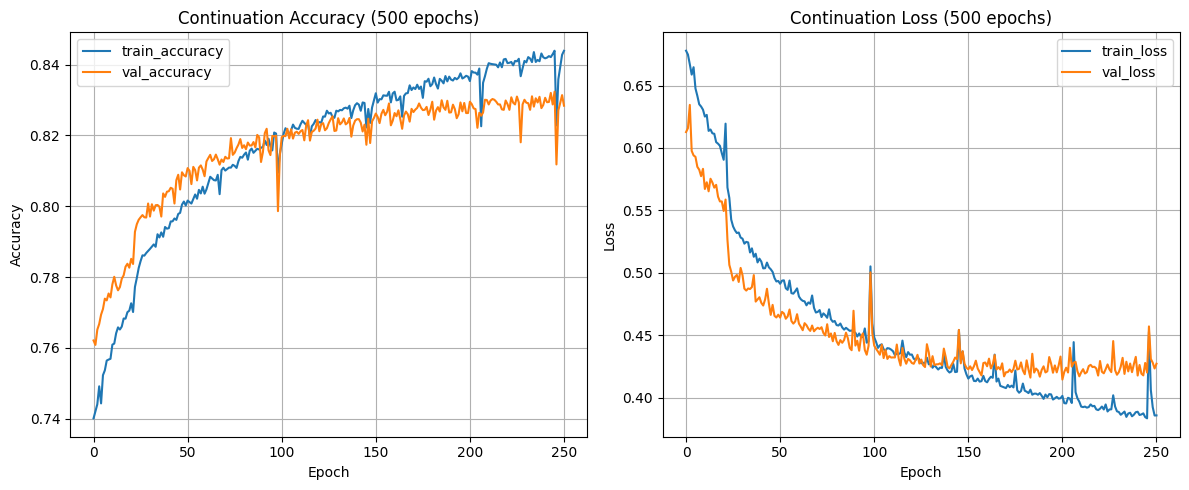

Saved consolidated metrics:
 - /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/rml2018/rml2018_checkpoint_metrics.json
 - /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/rml2018/rml2018_checkpoint_metrics.csv
Updated best checkpoint: /home/rameyjm7/workspace/ML-wireless-signal-classification/models/rml2018/checkpoints/best_checkpoint.txt
Best checkpoint: rml2018_lstm_continued_500_20260413_235547.keras eval_accuracy= 0.829514
\nClassification Report (best checkpoint):
              precision    recall  f1-score   support

     128APSK       0.61      0.71      0.66       600
      128QAM       0.80      0.69      0.74       600
      16APSK       0.92      0.90      0.91       600
       16PSK       0.88      0.79      0.83       600
       16QAM       0.88      0.92      0.90       600
      256QAM       0.90      0.82      0.86       600
      32APSK       0.87      0.84      0.85       600
       32PSK       0.98      0.99      0.99       600
  

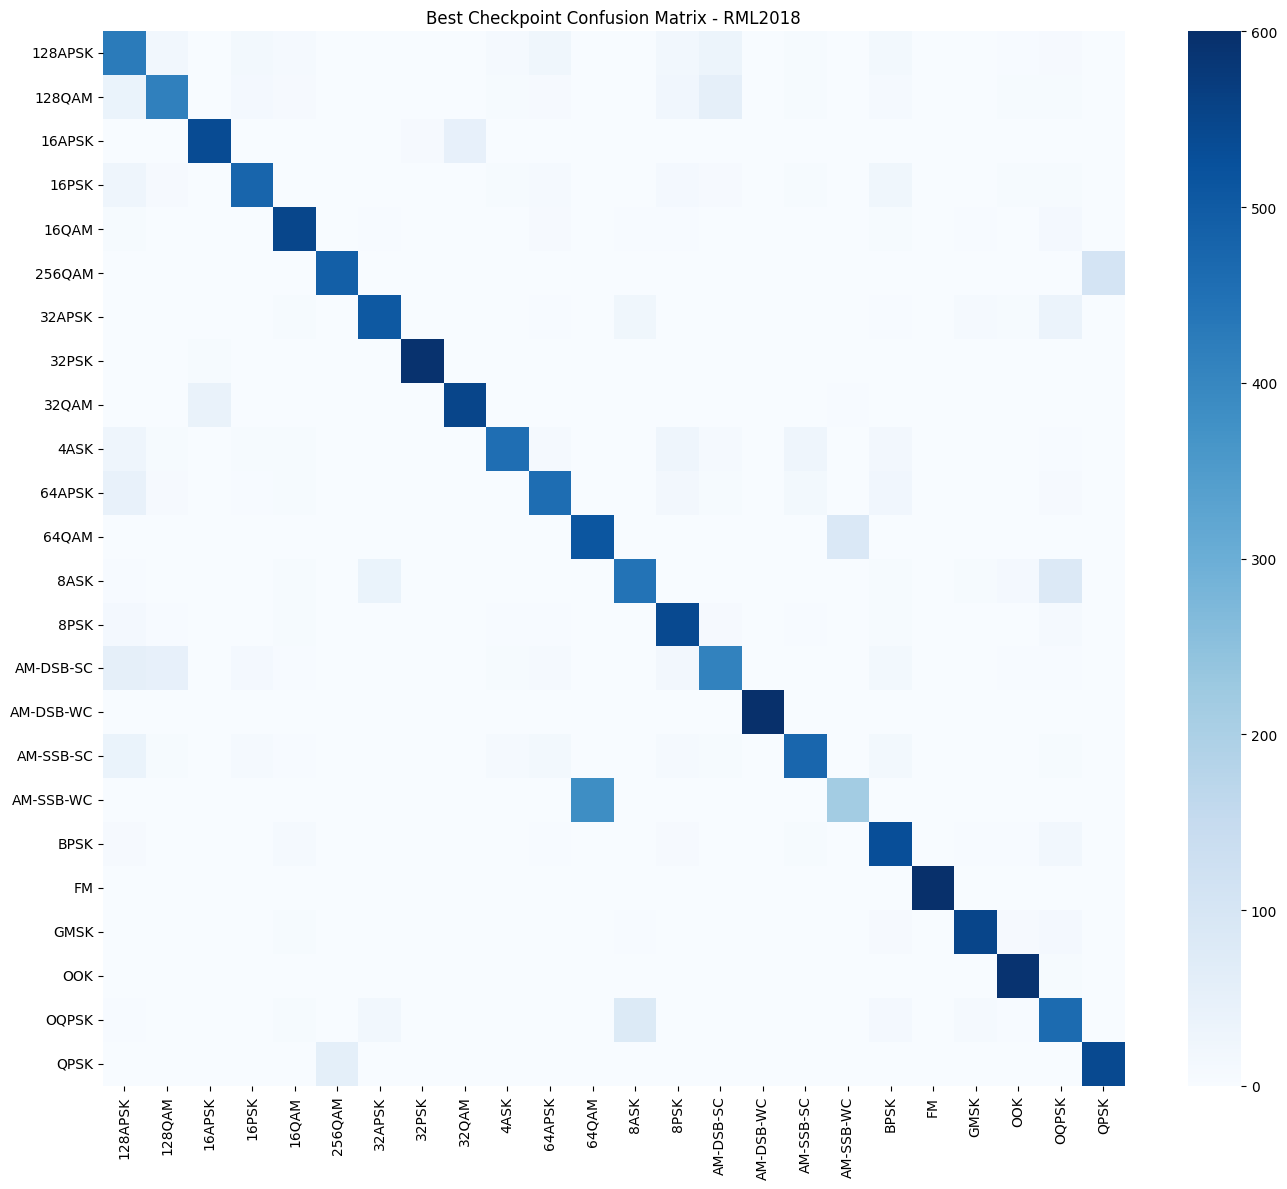

Saved confusion matrix figure: /home/rameyjm7/workspace/ML-wireless-signal-classification/outputs/rml2018/rml2018_lstm_continued_500_20260413_235547.keras.confusion_matrix.png


: 

In [ ]:
# Cell 2: Continue training for 500 epochs and persist full evaluation artifacts
import ast
import csv
import json
import random
from datetime import datetime
from pathlib import Path

import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# Paths and configuration (standalone for fresh kernel)
# ---------------------------------------------------------
notebook_dir = Path().resolve()
project_root = notebook_dir.parent

cfg_path = project_root / 'configs' / 'local_data_paths.yaml'
if cfg_path.exists():
    local_cfg = yaml.safe_load(cfg_path.read_text())
    rml2018_cfg = local_cfg.get('datasets', {}).get('rml2018', {})
    H5_PATH = Path(rml2018_cfg.get('hdf5', '/scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5'))
    CLASSES_PATH = Path(rml2018_cfg.get('classes', '/scratch/rameyjm7/datasets/RML2018/classes.txt'))
else:
    H5_PATH = Path('/scratch/rameyjm7/datasets/RML2018/GOLD_XYZ_OSC.0001_1024.hdf5')
    CLASSES_PATH = Path('/scratch/rameyjm7/datasets/RML2018/classes.txt')

DEFAULT_MODEL = project_root / 'models' / 'rml2018' / 'rml2018_lstm_rnn.keras'
ckpt_dir = project_root / 'models' / 'rml2018' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
outputs_dir = project_root / 'outputs' / 'rml2018'
outputs_dir.mkdir(parents=True, exist_ok=True)

MAX_SAMPLES_PER_CLASS = 3000
SNR_MIN_DB = -6
SNR_MAX_DB = 30
TEST_SPLIT = 0.20
RANDOM_STATE = 42
CONTINUE_EPOCHS = 500
CONTINUE_LR = 5e-5
BATCH = 64
AUTO_BATCH_CANDIDATES = [32, 64, 96, 128, 160, 192, 256]

print('Data HDF5:', H5_PATH)
print('Classes file:', CLASSES_PATH)
print('Default model:', DEFAULT_MODEL)
print('Checkpoint dir:', ckpt_dir)

# ---------------------------------------------------------
# Load best checkpoint if present; otherwise load default
# ---------------------------------------------------------
best_ckpt_txt = ckpt_dir / 'best_checkpoint.txt'
if best_ckpt_txt.exists():
    best_path = Path(best_ckpt_txt.read_text().strip())
    if best_path.exists():
        print('Loading best checkpoint:', best_path)
        model = load_model(best_path)
    else:
        print('best_checkpoint.txt exists but target is missing. Loading default model:', DEFAULT_MODEL)
        model = load_model(DEFAULT_MODEL)
else:
    print('Best checkpoint not found. Loading default model:', DEFAULT_MODEL)
    model = load_model(DEFAULT_MODEL)

# ---------------------------------------------------------
# Dataset loader + split
# ---------------------------------------------------------
def load_all_rml2018(h5_path, classes_txt, snr_min_db=6, snr_max_db=30, max_per_class=3000):
    with open(classes_txt, 'r') as f:
        class_list = ast.literal_eval(f.read().split('=')[-1].strip())
        class_list = [c.strip(" '") for c in class_list]

    with h5py.File(h5_path, 'r') as f:
        X, Y, Z = f['X'][:], f['Y'][:], f['Z'][:]

    per_class = {cls: [] for cls in class_list}

    for i in range(len(X)):
        snr = int(Z[i][0])
        if (snr > snr_min_db) and (snr <= snr_max_db):
            cls = class_list[int(Y[i].argmax())]
            sig = np.hstack([X[i], np.full((1024, 1), snr, dtype=np.float32)])
            per_class[cls].append(sig)

    if max_per_class:
        for k in per_class:
            random.shuffle(per_class[k])
            per_class[k] = per_class[k][:max_per_class]

    X_out, y_out = [], []
    for cls, arr in per_class.items():
        X_out.extend(arr)
        y_out.extend([cls] * len(arr))

    return np.array(X_out, dtype=np.float32), np.array(y_out), class_list

X_all, y_all, classes = load_all_rml2018(
    H5_PATH,
    CLASSES_PATH,
    snr_min_db=SNR_MIN_DB,
    snr_max_db=SNR_MAX_DB,
    max_per_class=MAX_SAMPLES_PER_CLASS,
)

le = LabelEncoder()
y_all_enc = le.fit_transform(y_all)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all,
    y_all_enc,
    test_size=TEST_SPLIT,
    stratify=y_all_enc,
    random_state=RANDOM_STATE,
)

print('SNR filter: snr >', SNR_MIN_DB, 'and snr <=', SNR_MAX_DB)
print('Train:', X_tr.shape, 'Test:', X_te.shape)

# ---------------------------------------------------------
# Auto batch-size selection
# ---------------------------------------------------------
def auto_select_batch_size(model, X_train, y_train, candidates, fallback=64):
    gpus = tf.config.list_physical_devices('GPU')
    if not gpus:
        print(f'No GPU detected. Using fallback batch size: {fallback}')
        return int(fallback)

    selected = None
    for b in sorted(set(int(x) for x in candidates), reverse=True):
        if b <= 0 or len(X_train) < b:
            continue
        try:
            tmp = tf.keras.models.clone_model(model)
            tmp.build(model.input_shape)
            tmp.set_weights(model.get_weights())
            tmp_opt = type(model.optimizer).from_config(model.optimizer.get_config())
            tmp.compile(optimizer=tmp_opt, loss=model.loss, metrics=['accuracy'])
            tmp.train_on_batch(X_train[:b], y_train[:b])
            selected = b
            print(f'Batch size {b} fits GPU memory.')
            break
        except tf.errors.ResourceExhaustedError:
            print(f'Batch size {b} OOM; trying smaller size...')
        except Exception as exc:
            print(f'Batch size {b} probe failed ({type(exc).__name__}); trying smaller size...')

    if selected is None:
        selected = int(fallback)
        print(f'No candidate batch size succeeded. Using fallback: {selected}')
    else:
        print(f'Selected batch size: {selected}')

    return selected

# ---------------------------------------------------------
# Continue training
# ---------------------------------------------------------
model.compile(
    optimizer=Adam(CONTINUE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

BATCH = auto_select_batch_size(
    model,
    X_tr,
    y_tr,
    candidates=AUTO_BATCH_CANDIDATES,
    fallback=BATCH,
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True,
    verbose=1,
)

history_cont = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_te, y_te),
    epochs=CONTINUE_EPOCHS,
    batch_size=BATCH,
    callbacks=[early_stopping],
    verbose=2,
)

# ---------------------------------------------------------
# Save continued checkpoint + metadata + raw history
# ---------------------------------------------------------
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
cont_name = f'rml2018_lstm_continued_500_{timestamp}.keras'
cont_path = ckpt_dir / cont_name
model.save(cont_path)
print('Saved continued checkpoint:', cont_path)

history_payload = {k: [float(x) for x in v] for k, v in history_cont.history.items()}
history_path = outputs_dir / f'{cont_name}.history.json'
with open(history_path, 'w') as f:
    json.dump(history_payload, f, indent=2)
print('Saved history:', history_path)

loss, acc = model.evaluate(X_te, y_te, verbose=0)
meta = {
    'timestamp': timestamp,
    'checkpoint': cont_name,
    'train_epochs': CONTINUE_EPOCHS,
    'lr': CONTINUE_LR,
    'batch': BATCH,
    'val_accuracy': float(history_cont.history['val_accuracy'][-1]),
    'train_accuracy': float(history_cont.history['accuracy'][-1]),
    'val_loss': float(history_cont.history['val_loss'][-1]),
    'train_loss': float(history_cont.history['loss'][-1]),
    'eval_accuracy': float(acc),
    'eval_loss': float(loss),
}
meta_path = ckpt_dir / f'{cont_name}.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved metadata:', meta_path)

# ---------------------------------------------------------
# Plot this continuation run (train vs validation)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cont.history['accuracy'], label='train_accuracy')
plt.plot(history_cont.history['val_accuracy'], label='val_accuracy')
plt.title('Continuation Accuracy (500 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cont.history['loss'], label='train_loss')
plt.plot(history_cont.history['val_loss'], label='val_loss')
plt.title('Continuation Loss (500 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Re-evaluate all RML2018 checkpoints and save consolidated metrics
# ---------------------------------------------------------
all_ckpts = sorted(ckpt_dir.glob('rml2018_lstm*.keras'))
all_results = []

for ckpt in all_ckpts:
    m = load_model(ckpt)
    e_loss, e_acc = m.evaluate(X_te, y_te, verbose=0)

    meta_file = ckpt_dir / f'{ckpt.name}.json'
    mdata = {}
    if meta_file.exists():
        with open(meta_file, 'r') as f:
            mdata = json.load(f)

    all_results.append({
        'checkpoint': ckpt.name,
        'path': str(ckpt),
        'timestamp': mdata.get('timestamp', ''),
        'meta_val_accuracy': mdata.get('val_accuracy'),
        'meta_train_accuracy': mdata.get('train_accuracy'),
        'meta_val_loss': mdata.get('val_loss'),
        'meta_train_loss': mdata.get('train_loss'),
        'eval_accuracy': float(e_acc),
        'eval_loss': float(e_loss),
    })

all_results.sort(key=lambda x: x['eval_accuracy'], reverse=True)

all_results_json = outputs_dir / 'rml2018_checkpoint_metrics.json'
with open(all_results_json, 'w') as f:
    json.dump(all_results, f, indent=2)

all_results_csv = outputs_dir / 'rml2018_checkpoint_metrics.csv'
fieldnames = [
    'checkpoint', 'path', 'timestamp',
    'meta_val_accuracy', 'meta_train_accuracy', 'meta_val_loss', 'meta_train_loss',
    'eval_accuracy', 'eval_loss',
]
with open(all_results_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_results)

print('Saved consolidated metrics:')
print(' -', all_results_json)
print(' -', all_results_csv)

best = all_results[0]
best_file = ckpt_dir / 'best_checkpoint.txt'
with open(best_file, 'w') as f:
    f.write(best['path'])
print('Updated best checkpoint:', best_file)
print('Best checkpoint:', best['checkpoint'], 'eval_accuracy=', round(best['eval_accuracy'], 6))

# ---------------------------------------------------------
# Re-evaluate best model and print report + confusion matrix
# ---------------------------------------------------------
best_model = load_model(best['path'])
y_prob = best_model.predict(X_te, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print('\\nClassification Report (best checkpoint):')
print(classification_report(y_te, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_te, y_pred)
cm_fig = outputs_dir / f"{best['checkpoint']}.confusion_matrix.png"
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Best Checkpoint Confusion Matrix - RML2018')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(cm_fig, dpi=180)
plt.show()
print('Saved confusion matrix figure:', cm_fig)




